##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os
import cv2
import math
import random
import shutil
import zipfile
import tarfile
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from collections import deque
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping


try:
    import yt_dlp
except ImportError:
    !pip -q install yt-dlp
    import yt_dlp

In [2]:
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)
print("Seeds set successfully.")

Seeds set successfully.


In [5]:
dataset_directory = r"----privete----"

print("Dataset directory:", dataset_directory)

Dataset directory: C:\Users\A NWAR DAHAN\Downloads\UCF11_updated_mpg


In [9]:
image_height, image_width = 64, 64
max_images_per_class = 4000

classes_list = ["walking", "trampoline_jumping", "horse_riding"]
model_output_size = len(classes_list)

print("Classes:", classes_list)
print("Number of classes:", model_output_size)

Classes: ['walking', 'trampoline_jumping', 'horse_riding']
Number of classes: 3


In [10]:
if dataset_directory is None:
    raise FileNotFoundError(
        "Dataset folder was not found. Please download/extract UCF11 and update dataset_directory."
    )

available_classes = sorted(os.listdir(dataset_directory))
print("Some available folders:", available_classes[:20])

for class_name in classes_list:
    class_path = os.path.join(dataset_directory, class_name)
    print(class_name, "->", os.path.isdir(class_path))

Some available folders: ['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking', 'walking']
walking -> True
trampoline_jumping -> True
horse_riding -> True


walking -> 123 videos found
trampoline_jumping -> 119 videos found
horse_riding -> 198 videos found


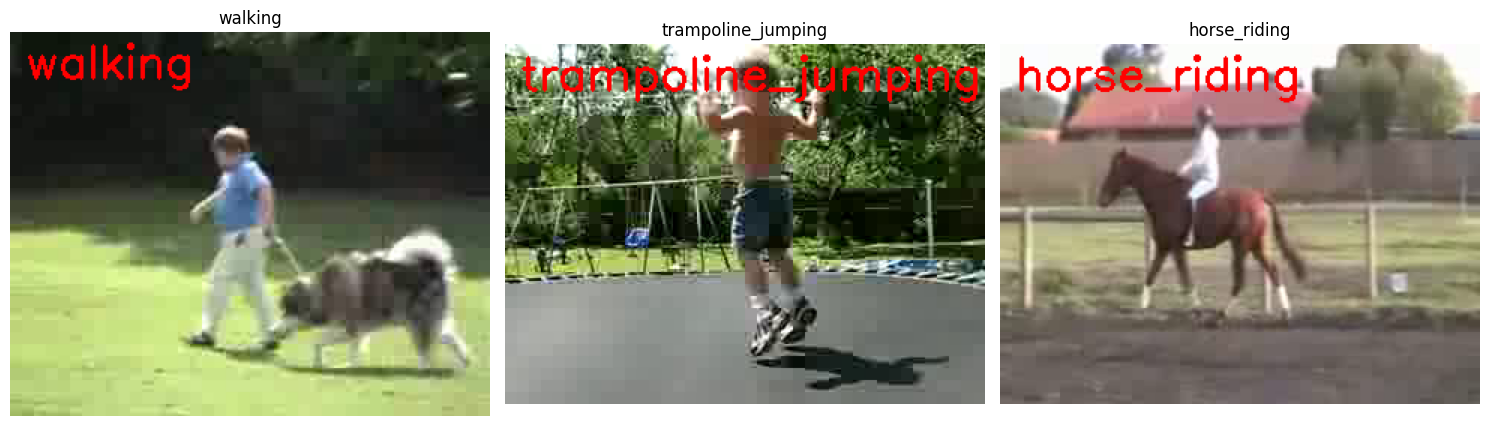

In [16]:

plt.figure(figsize=(15, 10))
plot_counter = 1

for class_name in classes_list:
    class_path = os.path.join(dataset_directory, class_name)
    video_files = []

    for root, _, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith((".mpg", ".avi", ".mp4", ".mov", ".mkv")):
                video_files.append(os.path.join(root, file))

    print(class_name, "->", len(video_files), "videos found")

    if len(video_files) == 0:
        print(f"No videos found for {class_name}")
        continue

    selected_video = random.choice(video_files)
    video_reader = cv2.VideoCapture(selected_video)
    success, frame = video_reader.read()
    video_reader.release()

    if success:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        cv2.putText(rgb_frame, class_name, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

        plt.subplot(1, 3, plot_counter)
        plt.imshow(rgb_frame)
        plt.title(class_name)
        plt.axis("off")
        plot_counter += 1

plt.tight_layout()
plt.show()

In [17]:
def frames_extraction(video_path, sequence_length=30):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)

    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = max(int(video_frames_count / sequence_length), 1)

    for frame_counter in range(sequence_length):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()

        if not success:
            break

        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list

In [18]:
def get_video_files(class_path):
    video_files = []
    for root, _, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith((".avi", ".mp4", ".mov", ".mkv")):
                video_files.append(os.path.join(root, file))
    return video_files


def create_dataset():
    temp_features = []
    features = []
    labels = []

    for class_index, class_name in enumerate(classes_list):
        print(f"Extracting data for class: {class_name}")
        class_path = os.path.join(dataset_directory, class_name)
        files_list = get_video_files(class_path)

        for video_file_path in files_list:
            frames = frames_extraction(video_file_path)
            temp_features.extend(frames)

        print(f"Total extracted frames for {class_name}: {len(temp_features)}")

        sample_count = min(max_images_per_class, len(temp_features))
        selected_frames = random.sample(temp_features, sample_count)

        features.extend(selected_frames)
        labels.extend([class_index] * sample_count)
        temp_features.clear()

    features = np.asarray(features)
    labels = np.asarray(labels)

    return features, labels

In [19]:
features, labels = create_dataset()

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

Extracting data for class: walking
Total extracted frames for walking: 0
Extracting data for class: trampoline_jumping
Total extracted frames for trampoline_jumping: 0
Extracting data for class: horse_riding
Total extracted frames for horse_riding: 0
Features shape: (0,)
Labels shape: (0,)


In [20]:
one_hot_encoded_labels = to_categorical(labels)
print("Encoded labels shape:", one_hot_encoded_labels.shape)

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    one_hot_encoded_labels,
    test_size=0.2,
    shuffle=True,
    random_state=seed_constant
)

print("Train features:", features_train.shape)
print("Test features:", features_test.shape)

In [ ]:
def create_model():
    model = Sequential()

    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu',
                     input_shape=(image_height, image_width, 3)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(model_output_size, activation='softmax'))

    model.summary()
    return model

model = create_model()
print("Model created successfully.")

In [ ]:
plot_model(model, to_file='ucf11_model_structure.png', show_shapes=True, show_layer_names=True)

In [ ]:
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min',
    restore_best_weights=True
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

model_training_history = model.fit(
    x=features_train,
    y=labels_train,
    epochs=10,
    batch_size=8,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)

In [ ]:
model_evaluation_history = model.evaluate(features_test, labels_test)
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

print(f"Test Loss: {model_evaluation_loss:.4f}")
print(f"Test Accuracy: {model_evaluation_accuracy:.4f}")

In [ ]:
student_name = "Anwar Aldahan"   # Replace with your actual name
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")

In [ ]:
def plot_metric(metric_name_1, metric_name_2, plot_name):
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]
    epochs = range(len(metric_value_1))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, metric_value_1, label=metric_name_1)
    plt.plot(epochs, metric_value_2, label=metric_name_2)
    plt.title(plot_name)
    plt.legend()
    plt.show()

plot_metric('loss', 'val_loss', 'Training Loss vs Validation Loss')
plot_metric('accuracy', 'val_accuracy', 'Training Accuracy vs Validation Accuracy')

In [ ]:
youtube_videos = {
    "horse_riding": "https://youtu.be/ohr_Vex4m4c?si=2gNGvPm1q4LJg6KI",
    "trampoline_jumping": "https://youtu.be/LMzBmhtTFlQ?si=8cSW8o611HODceQN",
    "walking": "https://youtu.be/84lYjtCfIvY?si=BwKAe72ECmRUit2S",
}

output_directory = "Youtube_Videos"
os.makedirs(output_directory, exist_ok=True)

def download_youtube_video(url, output_path_without_extension):
    ydl_opts = {
        "format": "mp4/bestvideo+bestaudio/best",
        "outtmpl": output_path_without_extension + ".%(ext)s",
        "quiet": False,
        "noplaylist": True,
        "merge_output_format": "mp4",
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

for label, url in youtube_videos.items():
    output_stub = os.path.join(output_directory, label)
    print(f"Downloading: {label}")
    download_youtube_video(url, output_stub)

In [ ]:
def predict_on_live_video(video_file_path, output_file_path, window_size=25):
    predicted_labels_probabilities_deque = deque(maxlen=window_size)
    video_reader = cv2.VideoCapture(video_file_path)

    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_writer = cv2.VideoWriter(
        output_file_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        24,
        (original_video_width, original_video_height)
    )

    while True:
        status, frame = video_reader.read()
        if not status:
            break

        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0), verbose=0
        )[0]

        predicted_labels_probabilities_deque.append(predicted_labels_probabilities)

        if len(predicted_labels_probabilities_deque) == window_size:
            predicted_labels_probabilities_np = np.array(predicted_labels_probabilities_deque)
            predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis=0)

            predicted_label = np.argmax(predicted_labels_probabilities_averaged)
            predicted_class_name = classes_list[predicted_label]

            cv2.putText(frame, predicted_class_name, (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        video_writer.write(frame)

    video_reader.release()
    video_writer.release()
    print(f"Saved predicted video to: {output_file_path}")

In [ ]:
def make_average_predictions(video_file_path, predictions_frames_count=50):
    predicted_labels_probabilities_np = np.zeros(
        (predictions_frames_count, model_output_size), dtype=float
    )

    video_reader = cv2.VideoCapture(video_file_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = max(1, video_frames_count // predictions_frames_count)

    for frame_counter in range(predictions_frames_count):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()
        if not success:
            continue

        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0

        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0), verbose=0
        )[0]

        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis=0)
    predicted_labels_probabilities_averaged_sorted_indexes = np.argsort(
        predicted_labels_probabilities_averaged
    )[::-1]

    print(f"Predictions for: {video_file_path}")
    for predicted_label in predicted_labels_probabilities_averaged_sorted_indexes:
        predicted_class_name = classes_list[predicted_label]
        predicted_probability = predicted_labels_probabilities_averaged[predicted_label]
        print(f"CLASS NAME: {predicted_class_name:<22} AVERAGED PROBABILITY: {predicted_probability:.4f}")

    video_reader.release()

In [ ]:
for label in youtube_videos.keys():
    video_path = os.path.join(output_directory, f"{label}.mp4")

    print("\n" + "="*70)
    print(f"Validation video for class: {label}")
    make_average_predictions(video_path, predictions_frames_count=50)

    output_video_path = os.path.join(output_directory, f"{label}_predicted.mp4")
    predict_on_live_video(video_path, output_video_path, window_size=25)